# Final EDA — Llama 3.1:8b + Mistral:7b Combined Analysis

Data sources: `llama.jsonl` (1,000 rows) + `mistral.jsonl` (1,000 rows mistral:7b)

This notebook produces all figures and statistics for the research paper.

In [1]:
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr, spearmanr
from pathlib import Path
import os, re

sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 150

# Resolve paths
NOTEBOOK_DIR = Path(os.getcwd())
PROJECT_ROOT = NOTEBOOK_DIR if (NOTEBOOK_DIR / 'llama.jsonl').exists() else NOTEBOOK_DIR.parent

# Load llama
llama_rows = [json.loads(l) for l in open(PROJECT_ROOT / 'llama.jsonl') if l.strip()]
# Load mistral (filter out 12 stale llama rows)
mistral_rows = [json.loads(l) for l in open(PROJECT_ROOT / 'mistral.jsonl') if l.strip()]
mistral_rows = [r for r in mistral_rows if r.get('model_name') == 'mistral:7b']

df_llama = pd.DataFrame(llama_rows)
df_mistral = pd.DataFrame(mistral_rows)
df = pd.concat([df_llama, df_mistral], ignore_index=True)

# Derived columns
df['agent_type'] = df['agent_name'].str.replace(r'_r\d+$', '', regex=True)
df['round'] = df['agent_name'].str.extract(r'_r(\d+)$').astype(int)
df['has_tools'] = df['has_tools'].astype(bool)
df['datetime'] = pd.to_datetime(df['timestamp'], unit='s')

print(f'Llama: {len(df_llama)} rows  |  Mistral: {len(df_mistral)} rows  |  Combined: {len(df)} rows')
print(f'Models: {df["model_name"].value_counts().to_dict()}')
print(f'Agent types: {sorted(df["agent_type"].unique())}')
print(f'Rounds: {df["round"].min()} - {df["round"].max()}')
print(f'\nNull counts: {df.isnull().sum().sum()}')
print(f'Errors: {df["error"].sum()}  |  Interruptions: {df["was_interrupted"].sum()}')
df.head(3)

Llama: 1000 rows  |  Mistral: 1000 rows  |  Combined: 2000 rows
Models: {'llama3.1:8b': 1000, 'mistral:7b': 1000}
Agent types: ['code_gen_agent', 'long_reasoning_agent', 'short_qa_agent', 'summarizer_agent', 'tool_use_agent']
Rounds: 1 - 20

Null counts: 0
Errors: 0  |  Interruptions: 0


,syscall_id,agent_name,model_name,timestamp,input_char_length,message_count,has_tools,max_tokens,temperature,created_time,start_time,end_time,latency_ms,wait_ms,was_interrupted,error,agent_type,round,datetime
0,450d403a-1bb2-4982-8536-a50588a65a5b,code_gen_agent_r1,llama3.1:8b,1.774864e+09,1014,6,False,1024,0.5,1.774864e+09,1.774864e+09,1.774864e+09,11813.774109,561.833620,False,False,code_gen_agent,1,2026-03-30 09:46:47.287215471
1,ad246991-4a61-4ce0-b1f8-015003ec7631,short_qa_agent_r1,llama3.1:8b,1.774864e+09,618,2,False,128,0.3,1.774864e+09,1.774864e+09,1.774864e+09,11033.238649,117.735386,False,False,short_qa_agent,1,2026-03-30 09:46:48.572995901
2,938d3bb5-3354-4cb1-9463-c6aacca5308b,summarizer_agent_r1,llama3.1:8b,1.774864e+09,2424,2,False,256,0.1,1.774864e+09,1.774864e+09,1.774864e+09,7843.859673,10999.394655,False,False,summarizer_agent,1,2026-03-30 09:47:00.216817141


## 1. Dataset Overview — Feature Distributions

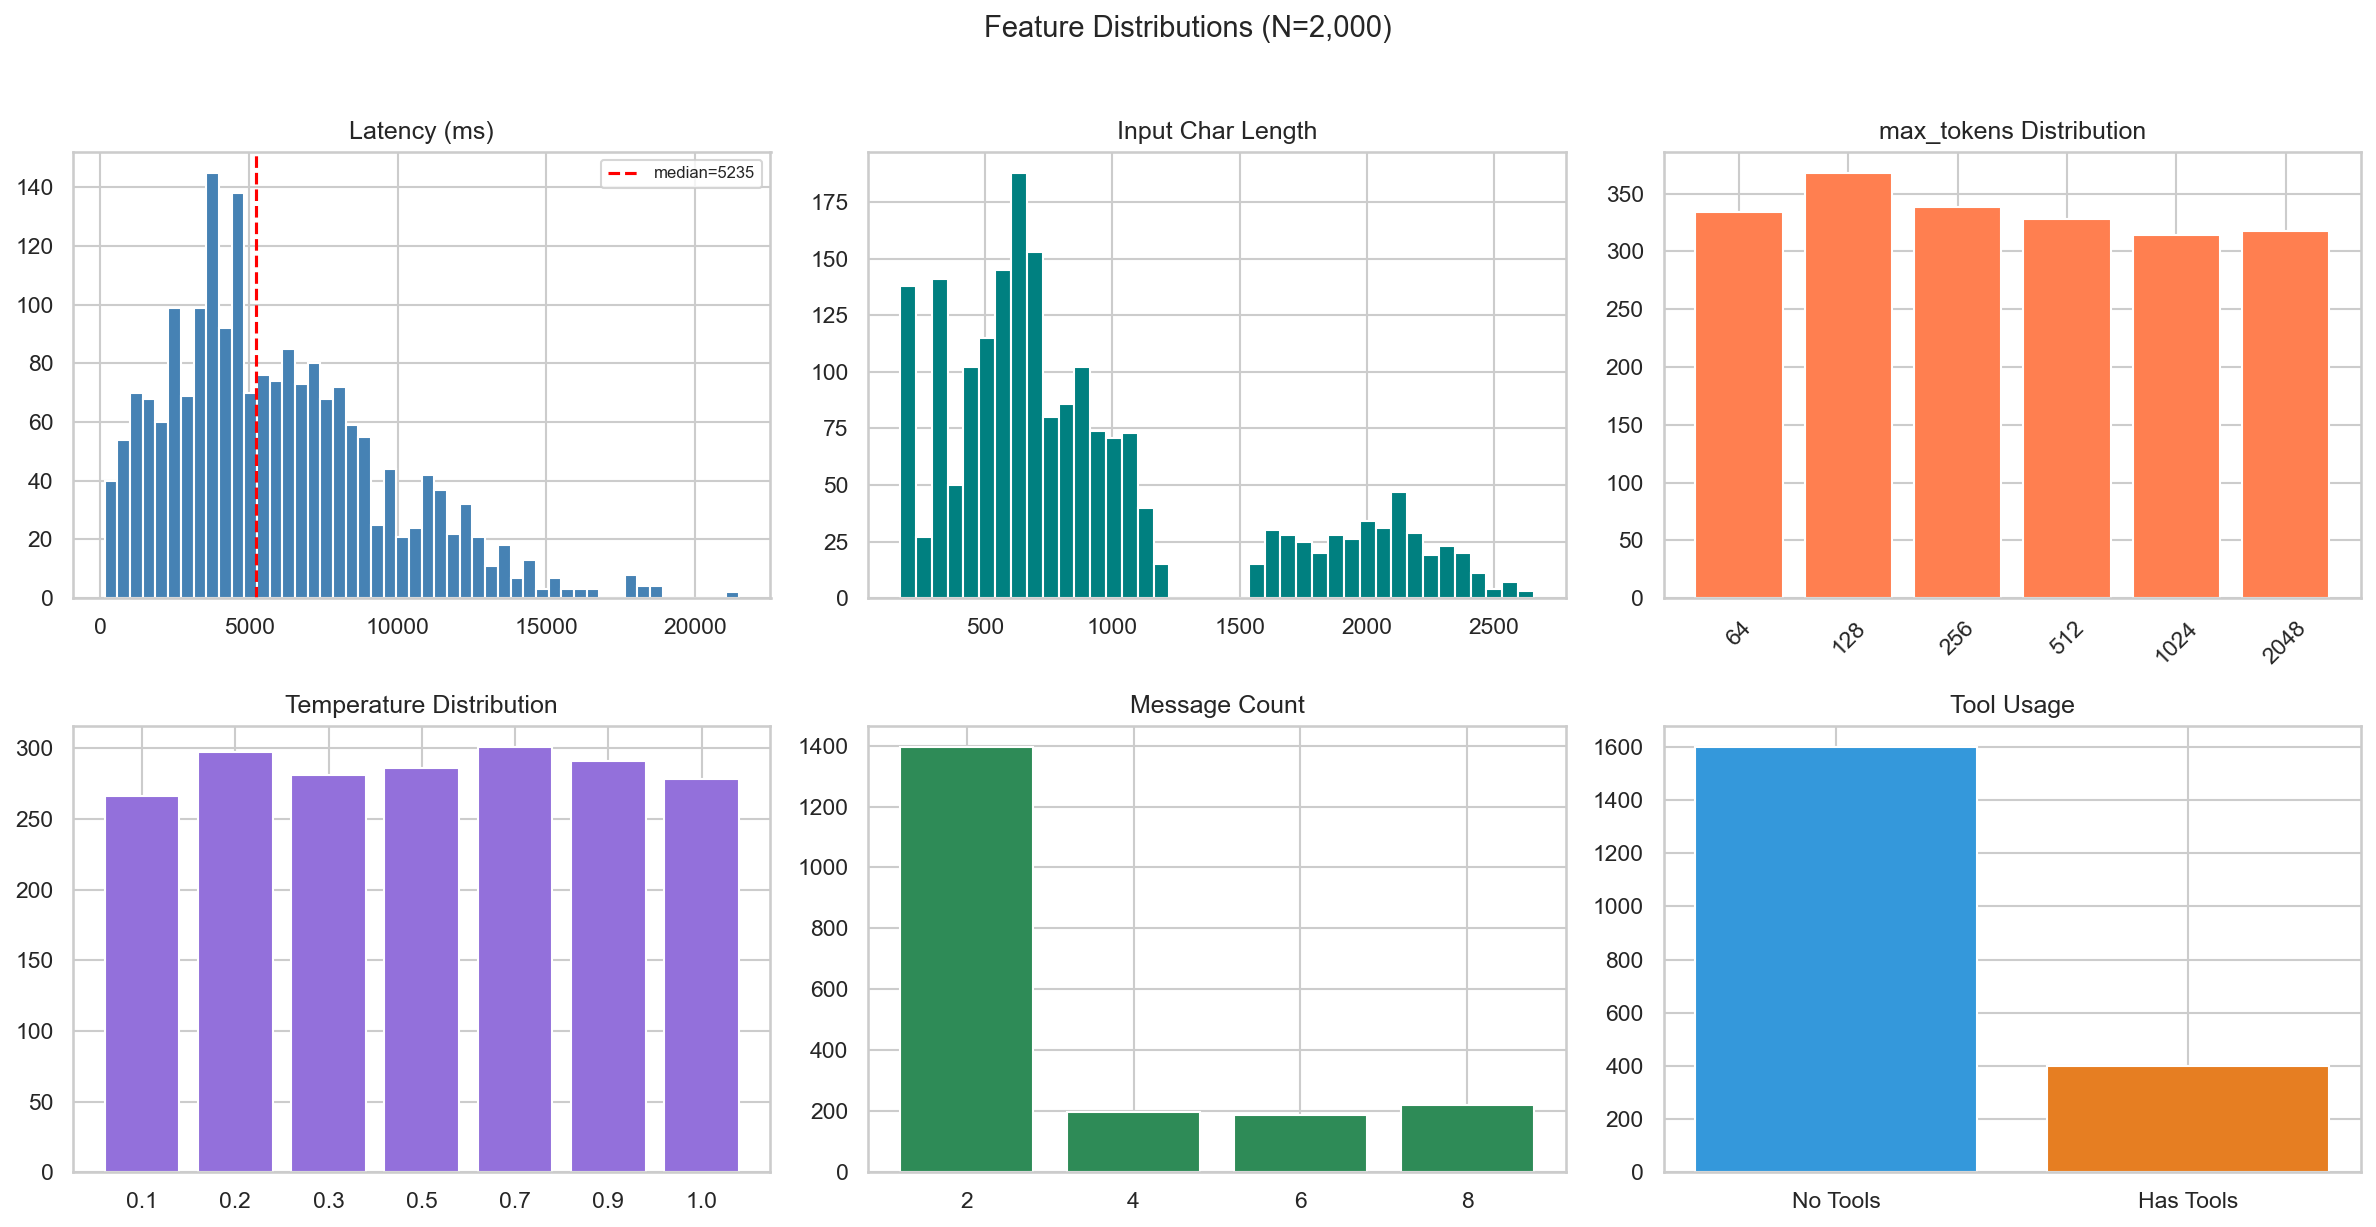

       latency_ms  wait_ms  input_char_length  message_count  max_tokens  \
count      2000.0   2000.0             2000.0         2000.0      2000.0   
mean       5931.7   1898.4              909.3            3.2       647.9   
std        3631.2   2299.0              611.3            2.1       685.4   
min         143.1    102.5              165.0            2.0        64.0   
25%        3245.8    394.5              504.0            2.0       128.0   
50%        5235.1    902.3              698.0            2.0       256.0   
75%        8066.5   2607.0             1057.0            4.0      1024.0   
max       21484.5  16196.5             2658.0            8.0      2048.0   

       temperature  
count       2000.0  
mean           0.5  
std            0.3  
min            0.1  
25%            0.2  
50%            0.5  
75%            0.9  
max            1.0  


In [2]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8))

# Latency
axes[0,0].hist(df['latency_ms'], bins=50, color='steelblue', edgecolor='white')
axes[0,0].set_title('Latency (ms)')
axes[0,0].axvline(df['latency_ms'].median(), color='red', ls='--', label=f'median={df.latency_ms.median():.0f}')
axes[0,0].legend(fontsize=8)

# input_char_length
axes[0,1].hist(df['input_char_length'], bins=40, color='teal', edgecolor='white')
axes[0,1].set_title('Input Char Length')

# max_tokens
vc_tok = df['max_tokens'].value_counts().sort_index()
axes[0,2].bar(vc_tok.index.astype(str), vc_tok.values, color='coral', edgecolor='white')
axes[0,2].set_title('max_tokens Distribution')
axes[0,2].tick_params(axis='x', rotation=45)

# temperature
vc_temp = df['temperature'].value_counts().sort_index()
axes[1,0].bar(vc_temp.index.astype(str), vc_temp.values, color='mediumpurple', edgecolor='white')
axes[1,0].set_title('Temperature Distribution')

# message_count
vc_msg = df['message_count'].value_counts().sort_index()
axes[1,1].bar(vc_msg.index.astype(str), vc_msg.values, color='seagreen', edgecolor='white')
axes[1,1].set_title('Message Count')

# has_tools
vc_tools = df['has_tools'].value_counts()
axes[1,2].bar(['No Tools', 'Has Tools'], [vc_tools.get(False,0), vc_tools.get(True,0)],
              color=['#3498db','#e67e22'], edgecolor='white')
axes[1,2].set_title('Tool Usage')

plt.suptitle('Feature Distributions (N=2,000)', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(PROJECT_ROOT / 'models' / 'feature_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

# Print summary stats
print(df[['latency_ms','wait_ms','input_char_length','message_count','max_tokens','temperature']].describe().round(1))

## 2. Latency Comparison: Llama vs Mistral

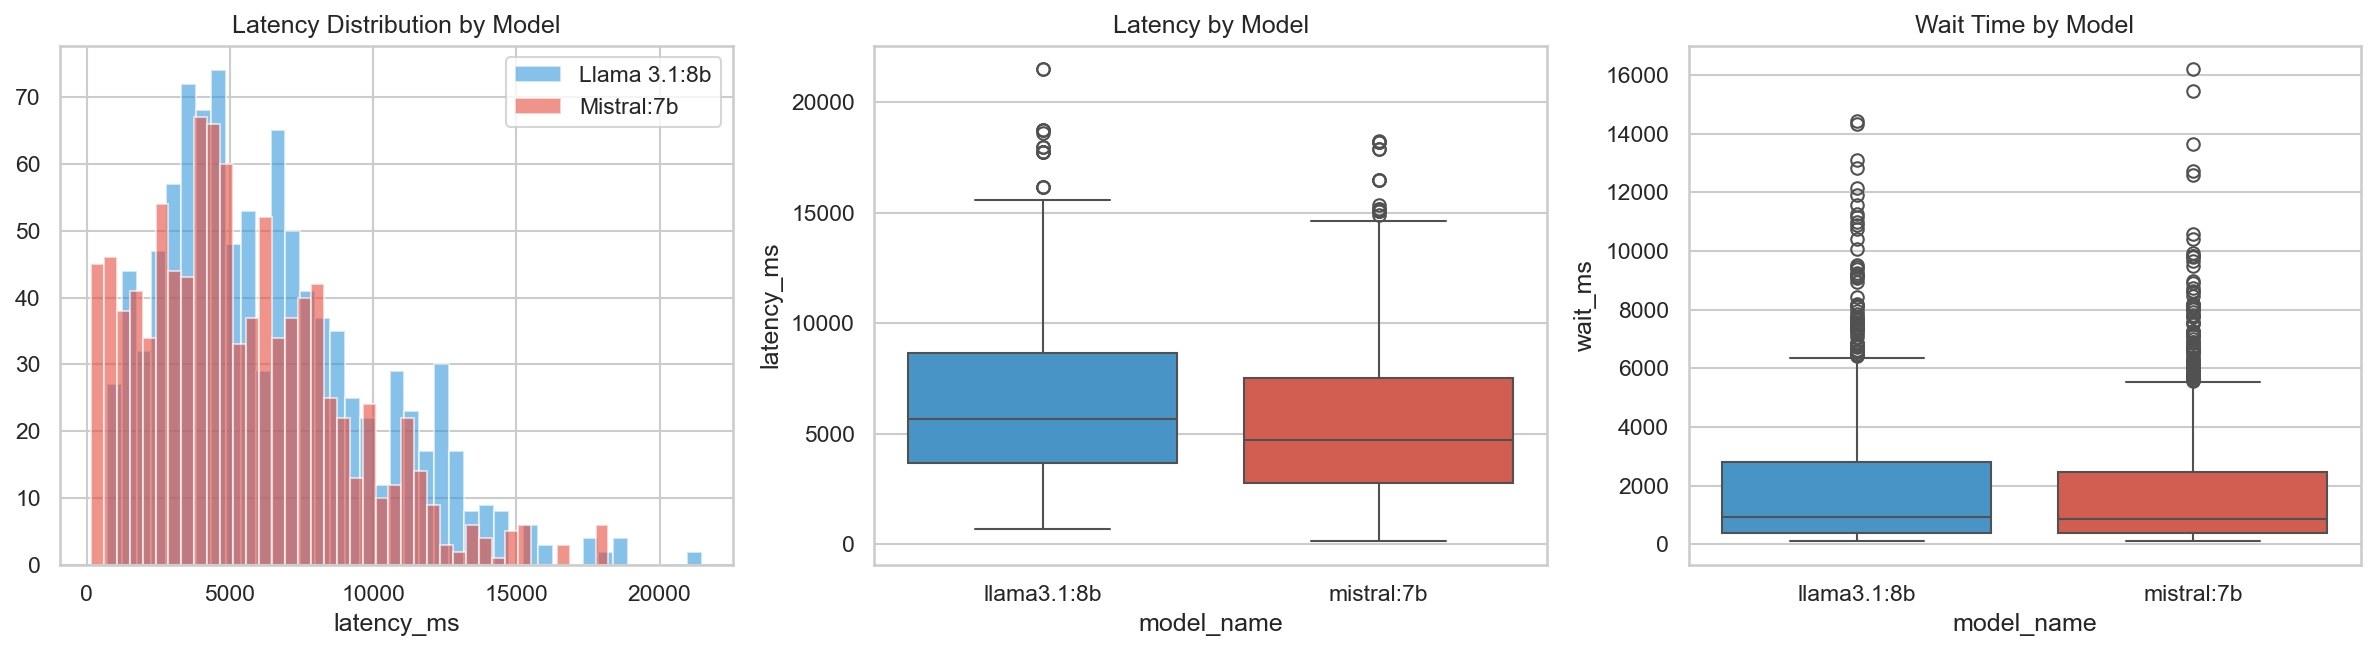

llama3.1:8b: median=5657ms  mean=6423ms  std=3699ms
mistral:7b: median=4738ms  mean=5440ms  std=3496ms


In [3]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

# Overlapping histograms
axes[0].hist(df[df.model_name=='llama3.1:8b']['latency_ms'], bins=40, alpha=0.6, color='#3498db', label='Llama 3.1:8b', edgecolor='white')
axes[0].hist(df[df.model_name=='mistral:7b']['latency_ms'], bins=40, alpha=0.6, color='#e74c3c', label='Mistral:7b', edgecolor='white')
axes[0].set_title('Latency Distribution by Model')
axes[0].set_xlabel('latency_ms')
axes[0].legend()

# Box plot
sns.boxplot(data=df, x='model_name', y='latency_ms', hue='model_name',
            palette={'llama3.1:8b':'#3498db','mistral:7b':'#e74c3c'}, legend=False, ax=axes[1])
axes[1].set_title('Latency by Model')

# Wait time comparison
sns.boxplot(data=df, x='model_name', y='wait_ms', hue='model_name',
            palette={'llama3.1:8b':'#3498db','mistral:7b':'#e74c3c'}, legend=False, ax=axes[2])
axes[2].set_title('Wait Time by Model')

plt.tight_layout()
plt.savefig(PROJECT_ROOT / 'models' / 'model_comparison_latency.png', dpi=150, bbox_inches='tight')
plt.show()

# Stats
for model in ['llama3.1:8b', 'mistral:7b']:
    sub = df[df.model_name == model]
    print(f'{model}: median={sub.latency_ms.median():.0f}ms  mean={sub.latency_ms.mean():.0f}ms  std={sub.latency_ms.std():.0f}ms')

## 3. Latency by Agent Type

,count,latency_median,latency_mean,latency_std,wait_mean,char_mean
agent_type,,,,,,
short_qa_agent,400,4721.2,5403.7,3581.0,2180.4,422.0
tool_use_agent,400,4818.2,5586.8,3568.5,1971.9,539.4
summarizer_agent,400,4938.8,5811.7,3525.5,2058.4,2014.6
code_gen_agent,400,5873.0,6550.3,3695.8,1608.9,871.2
long_reasoning_agent,400,5945.8,6305.9,3671.3,1672.6,699.4


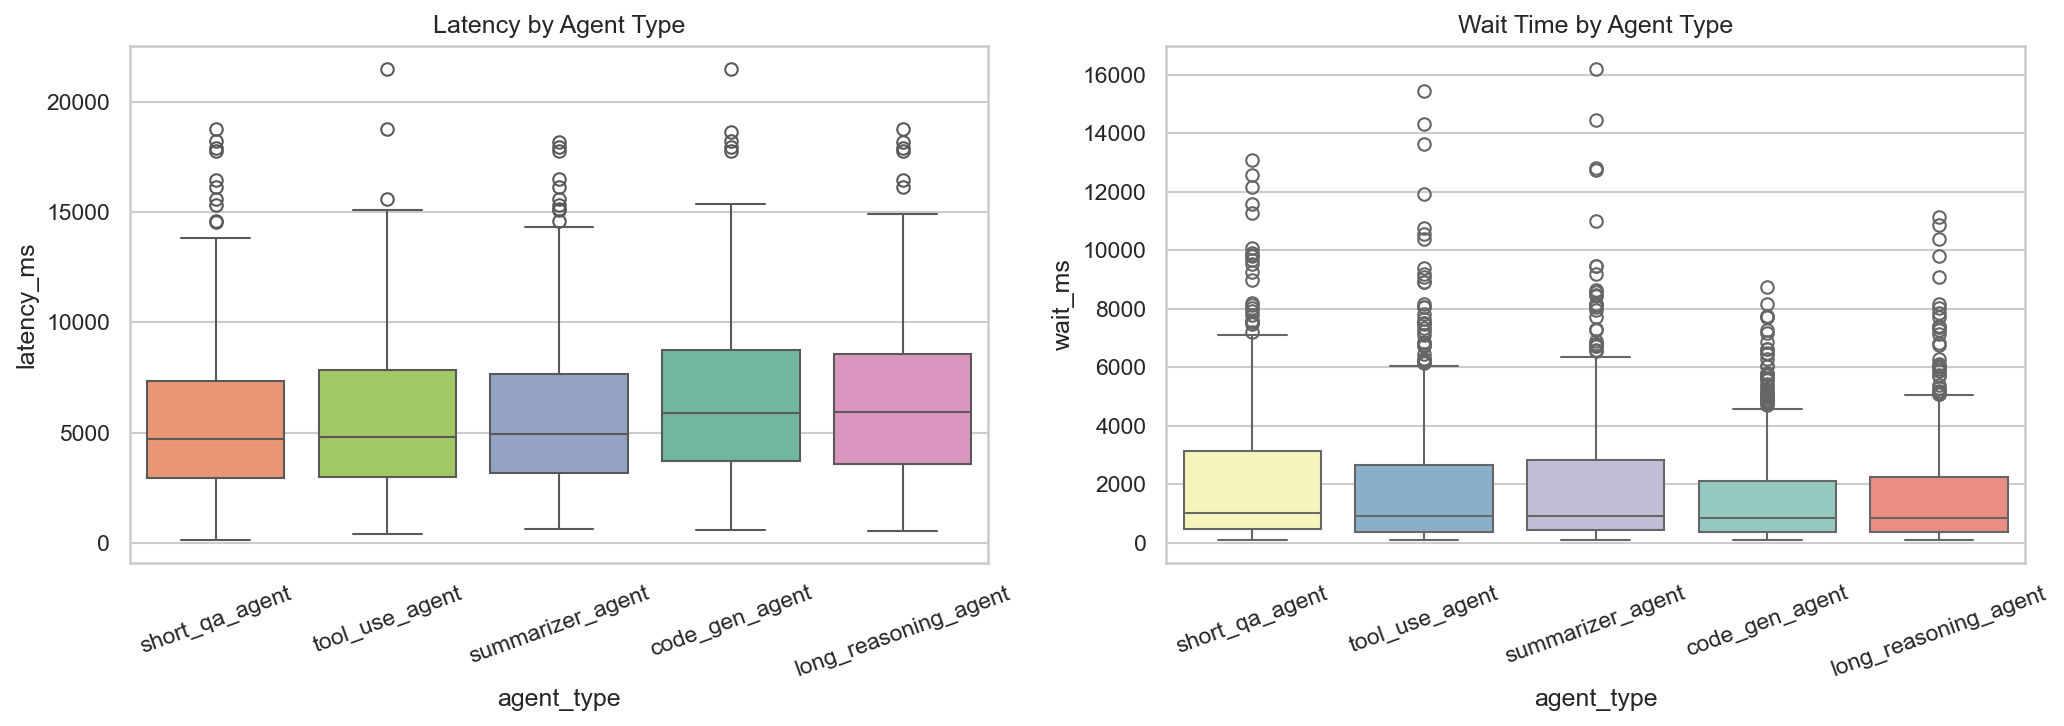

In [4]:
agent_stats = (
    df.groupby('agent_type')
    .agg(
        count=('latency_ms', 'size'),
        latency_median=('latency_ms', 'median'),
        latency_mean=('latency_ms', 'mean'),
        latency_std=('latency_ms', 'std'),
        wait_mean=('wait_ms', 'mean'),
        char_mean=('input_char_length', 'mean'),
    )
    .round(1)
    .sort_values('latency_median')
)
display(agent_stats)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

order = agent_stats.index.tolist()
sns.boxplot(data=df, x='agent_type', y='latency_ms', order=order,
            hue='agent_type', palette='Set2', legend=False, ax=axes[0])
axes[0].set_title('Latency by Agent Type')
axes[0].tick_params(axis='x', rotation=20)

sns.boxplot(data=df, x='agent_type', y='wait_ms', order=order,
            hue='agent_type', palette='Set3', legend=False, ax=axes[1])
axes[1].set_title('Wait Time by Agent Type')
axes[1].tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.savefig(PROJECT_ROOT / 'models' / 'agent_type_latency.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Feature-Latency Correlations

Feature                    Pearson r  Spearman rho      p-value
--------------------------------------------------------------
input_char_length              0.021         0.049     2.88e-02
message_count                 -0.018        -0.013     5.65e-01
has_tools                     -0.047        -0.045     4.29e-02
max_tokens                     0.202         0.206     1.49e-20 ***
temperature                    0.030         0.031     1.72e-01
is_llama                       0.135         0.132     3.16e-09


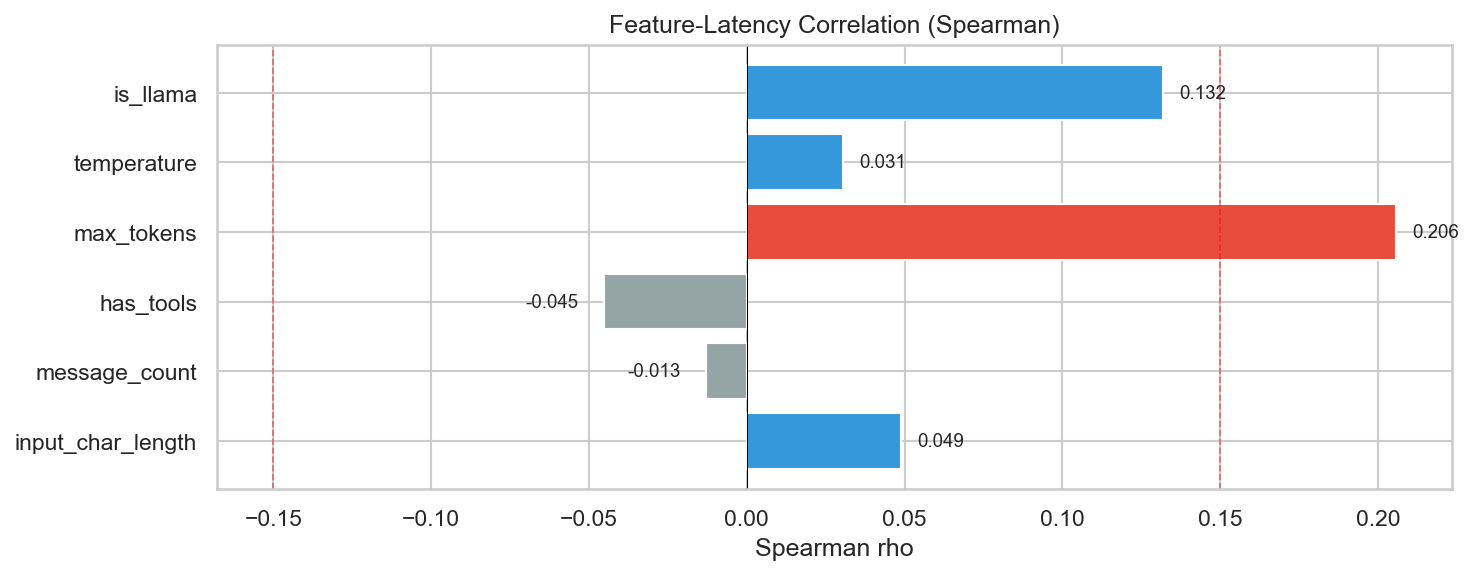

In [5]:
df_num = df.copy()
df_num['has_tools'] = df_num['has_tools'].astype(int)
df_num['is_llama'] = (df_num['model_name'] == 'llama3.1:8b').astype(int)

features = ['input_char_length', 'message_count', 'has_tools', 'max_tokens', 'temperature', 'is_llama']

print(f'{"Feature":<25} {"Pearson r":>10} {"Spearman rho":>13} {"p-value":>12}')
print('-' * 62)
spearman_vals = {}
for feat in features:
    if df_num[feat].std() == 0:
        print(f'{feat:<25} {"CONSTANT":>10}')
        continue
    pr, _ = pearsonr(df_num[feat], df_num['latency_ms'])
    sr, sp = spearmanr(df_num[feat], df_num['latency_ms'])
    spearman_vals[feat] = sr
    flag = ' ***' if abs(sr) >= 0.15 else ''
    print(f'{feat:<25} {pr:>10.3f} {sr:>13.3f} {sp:>12.2e}{flag}')

# Bar chart of Spearman rho
fig, ax = plt.subplots(figsize=(10, 4))
names = list(spearman_vals.keys())
vals = [spearman_vals[n] for n in names]
colors = ['#e74c3c' if v >= 0.15 else '#3498db' if v >= 0 else '#95a5a6' for v in vals]
ax.barh(names, vals, color=colors, edgecolor='white')
ax.set_xlabel('Spearman rho')
ax.set_title('Feature-Latency Correlation (Spearman)')
ax.axvline(0, color='black', lw=0.5)
ax.axvline(0.15, color='red', ls='--', lw=0.8, alpha=0.5)
ax.axvline(-0.15, color='red', ls='--', lw=0.8, alpha=0.5)
for i, v in enumerate(vals):
    ax.text(v + 0.005 if v >= 0 else v - 0.025, i, f'{v:.3f}', va='center', fontsize=9)
plt.tight_layout()
plt.savefig(PROJECT_ROOT / 'models' / 'correlation_bars.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Correlation Heatmap

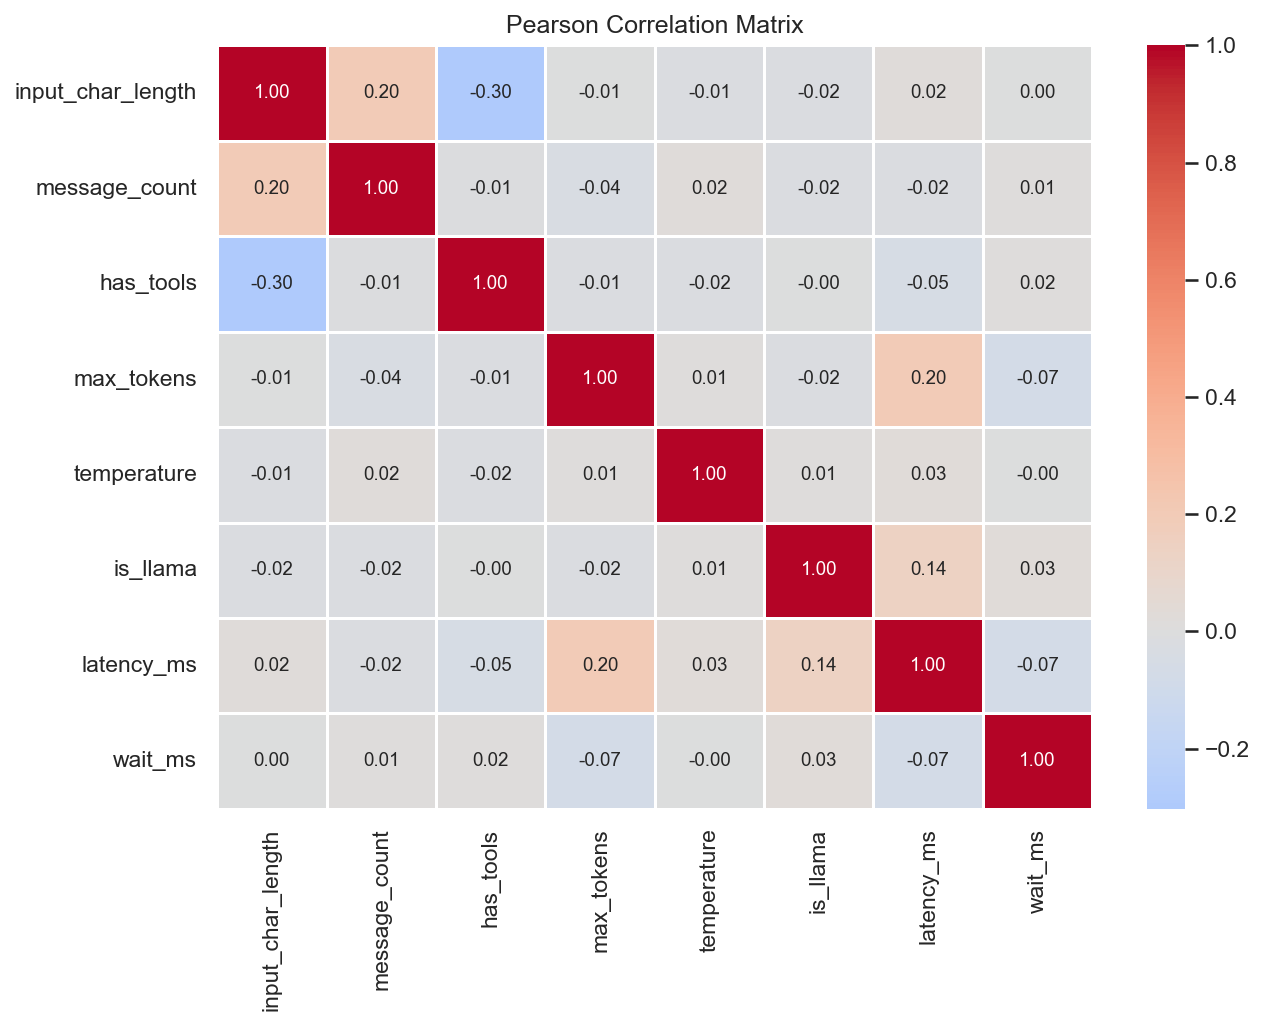

In [6]:
corr_cols = ['input_char_length', 'message_count', 'has_tools', 'max_tokens', 'temperature', 'is_llama', 'latency_ms', 'wait_ms']
corr_df = df_num[corr_cols].corr()

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(corr_df, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            linewidths=0.5, ax=ax, annot_kws={'size': 9})
ax.set_title('Pearson Correlation Matrix')
plt.tight_layout()
plt.savefig(PROJECT_ROOT / 'models' / 'correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Scatter: max_tokens vs Latency (key relationship)

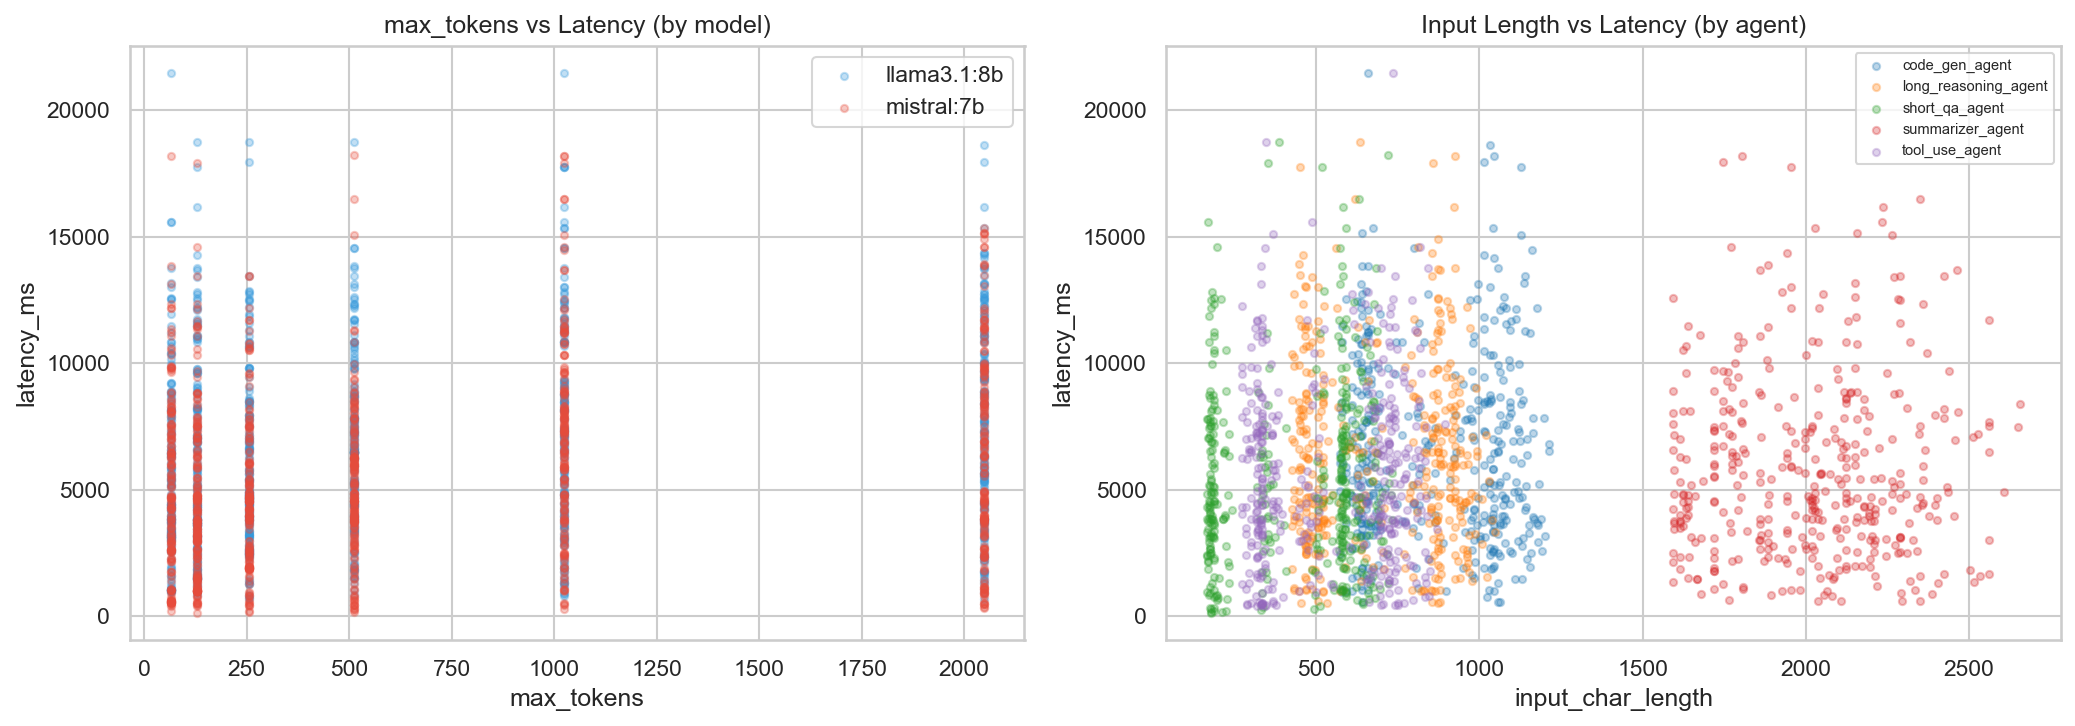

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

palette = {'llama3.1:8b': '#3498db', 'mistral:7b': '#e74c3c'}
for model, grp in df.groupby('model_name'):
    axes[0].scatter(grp['max_tokens'], grp['latency_ms'], alpha=0.3, s=12, label=model, color=palette.get(model))
axes[0].set_xlabel('max_tokens')
axes[0].set_ylabel('latency_ms')
axes[0].set_title('max_tokens vs Latency (by model)')
axes[0].legend()

agent_palette = sns.color_palette('tab10', n_colors=df['agent_type'].nunique())
agent_colors = {a: agent_palette[i] for i, a in enumerate(sorted(df['agent_type'].unique()))}
for agent, grp in df.groupby('agent_type'):
    axes[1].scatter(grp['input_char_length'], grp['latency_ms'], alpha=0.3, s=12, label=agent, color=agent_colors[agent])
axes[1].set_xlabel('input_char_length')
axes[1].set_ylabel('latency_ms')
axes[1].set_title('Input Length vs Latency (by agent)')
axes[1].legend(fontsize=7)

plt.tight_layout()
plt.savefig(PROJECT_ROOT / 'models' / 'scatter_features_vs_latency.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Wait Time Analysis

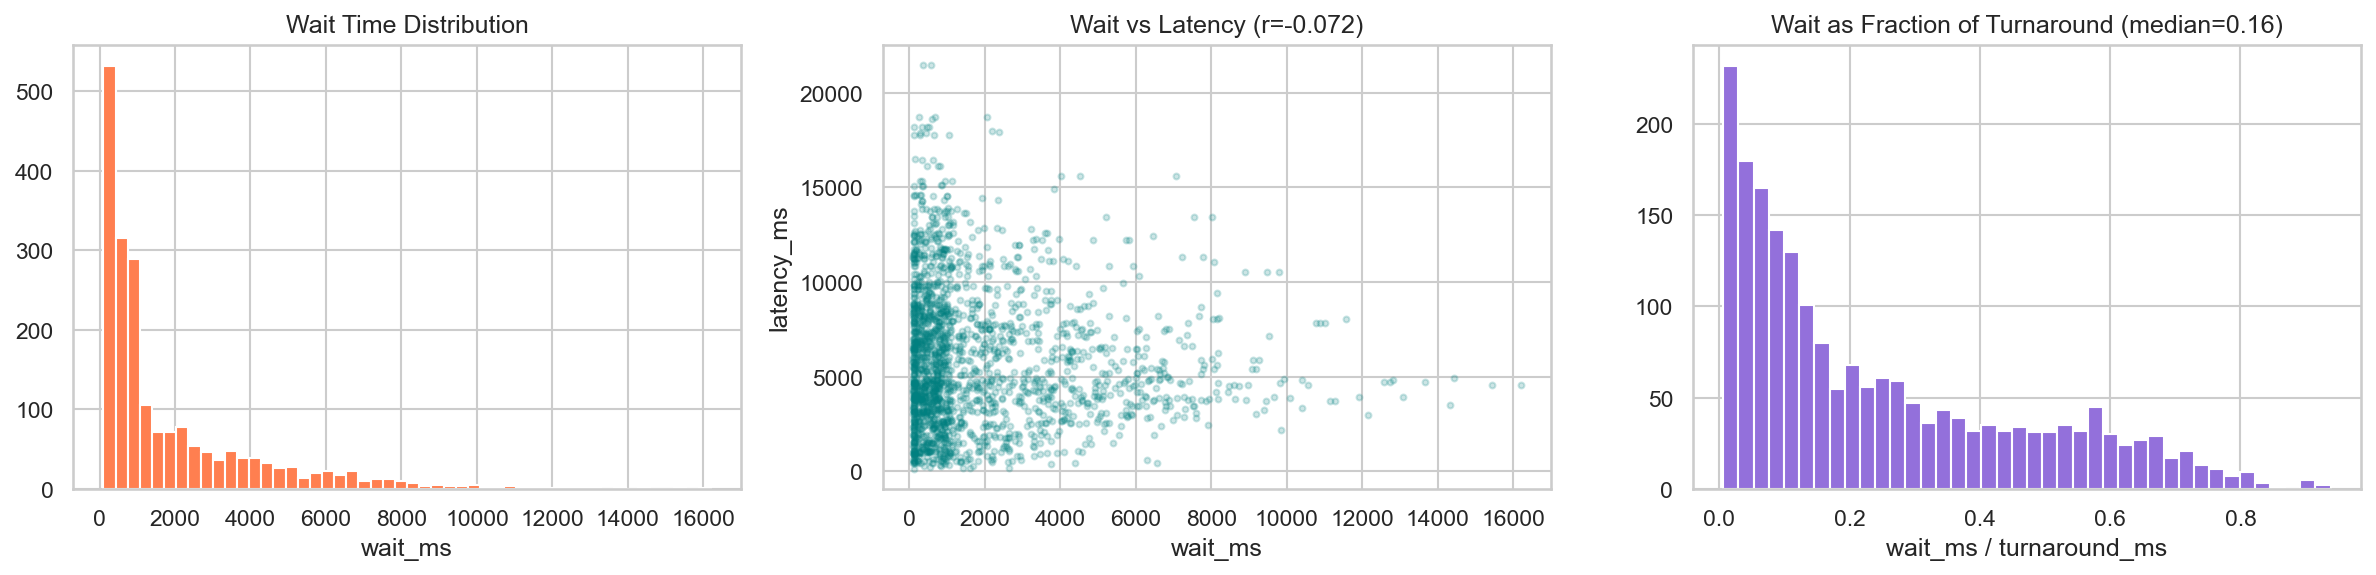

Wait time: median=902ms  mean=1898ms  max=16196ms
Wait fraction: median=0.16  mean=0.24


In [8]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].hist(df['wait_ms'], bins=50, color='coral', edgecolor='white')
axes[0].set_title('Wait Time Distribution')
axes[0].set_xlabel('wait_ms')

axes[1].scatter(df['wait_ms'], df['latency_ms'], alpha=0.2, s=8, color='teal')
r, _ = pearsonr(df['wait_ms'], df['latency_ms'])
axes[1].set_title(f'Wait vs Latency (r={r:.3f})')
axes[1].set_xlabel('wait_ms')
axes[1].set_ylabel('latency_ms')

# Wait as fraction of total turnaround
df['turnaround_ms'] = df['latency_ms'] + df['wait_ms']
df['wait_fraction'] = df['wait_ms'] / df['turnaround_ms']
axes[2].hist(df['wait_fraction'], bins=40, color='mediumpurple', edgecolor='white')
axes[2].set_title(f'Wait as Fraction of Turnaround (median={df.wait_fraction.median():.2f})')
axes[2].set_xlabel('wait_ms / turnaround_ms')

plt.tight_layout()
plt.savefig(PROJECT_ROOT / 'models' / 'wait_time_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Wait time: median={df.wait_ms.median():.0f}ms  mean={df.wait_ms.mean():.0f}ms  max={df.wait_ms.max():.0f}ms')
print(f'Wait fraction: median={df.wait_fraction.median():.2f}  mean={df.wait_fraction.mean():.2f}')

## 8. Complexity Class Distribution (Percentile Thresholds)

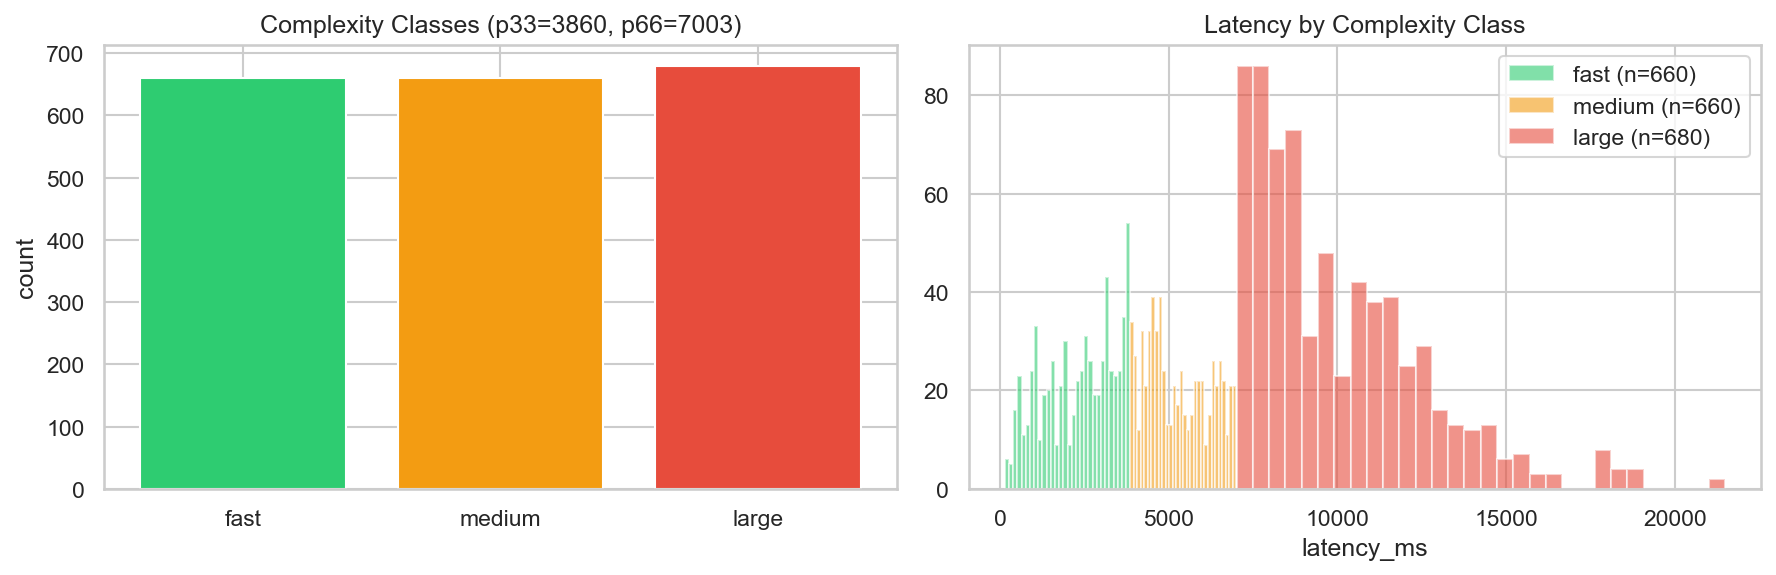

Thresholds: fast < 3860ms | medium < 7003ms | large >= 7003ms
  fast: 660 (33.0%)
  medium: 660 (33.0%)
  large: 680 (34.0%)


In [9]:
p33 = df['latency_ms'].quantile(0.33)
p66 = df['latency_ms'].quantile(0.66)

def label(ms):
    if ms < p33: return 'fast'
    if ms < p66: return 'medium'
    return 'large'

df['complexity'] = df['latency_ms'].apply(label)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

counts = df['complexity'].value_counts()
colors_map = {'fast': '#2ecc71', 'medium': '#f39c12', 'large': '#e74c3c'}
axes[0].bar(['fast', 'medium', 'large'],
            [counts.get('fast',0), counts.get('medium',0), counts.get('large',0)],
            color=[colors_map['fast'], colors_map['medium'], colors_map['large']], edgecolor='white')
axes[0].set_title(f'Complexity Classes (p33={p33:.0f}, p66={p66:.0f})')
axes[0].set_ylabel('count')

# Latency distribution per class
for cls, color in colors_map.items():
    sub = df[df.complexity == cls]['latency_ms']
    axes[1].hist(sub, bins=30, alpha=0.6, color=color, label=f'{cls} (n={len(sub)})', edgecolor='white')
axes[1].set_title('Latency by Complexity Class')
axes[1].set_xlabel('latency_ms')
axes[1].legend()

plt.tight_layout()
plt.savefig(PROJECT_ROOT / 'models' / 'complexity_classes.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Thresholds: fast < {p33:.0f}ms | medium < {p66:.0f}ms | large >= {p66:.0f}ms')
for cls in ['fast','medium','large']:
    n = counts.get(cls,0)
    pct = n/len(df)*100
    print(f'  {cls}: {n} ({pct:.1f}%)')

## 9. Classifier Results

,model,train_acc,test_acc,test_f1,overfit_gap,diagnosis
0,Gradient Boosting,0.665163,0.438786,0.438094,0.226377,HIGH BIAS (underfitting)
1,Random Forest,0.990367,0.405226,0.403754,0.585140,HIGH BIAS (underfitting)
2,Decision Tree,0.990367,0.389069,0.388423,0.601297,HIGH BIAS (underfitting)
3,SVM (RBF),0.484154,0.399007,0.382942,0.085147,HIGH BIAS (underfitting)
4,KNN (k=5),0.577999,0.397159,0.382156,0.180839,HIGH BIAS (underfitting)
5,Logistic Regression,0.411747,0.394652,0.380788,0.017095,HIGH BIAS (underfitting)


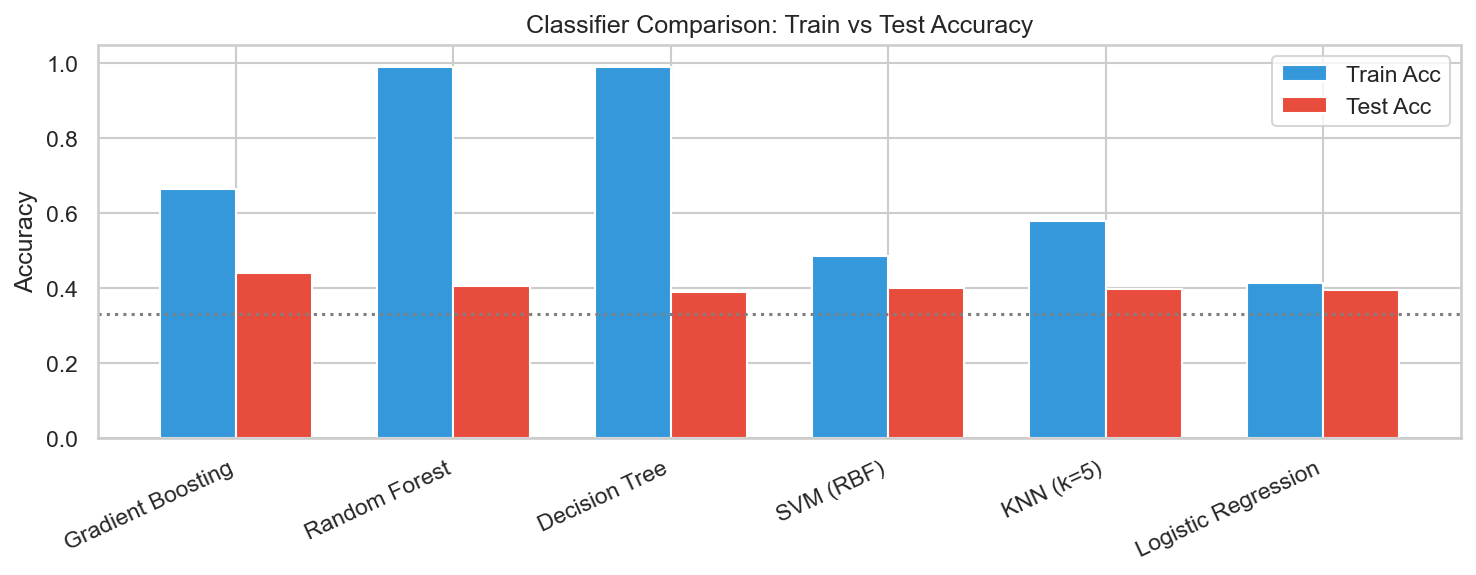

In [10]:
# Load saved comparison results
import csv
comp_path = PROJECT_ROOT / 'models' / 'comparison_results.csv'
if comp_path.exists():
    comp_df = pd.read_csv(comp_path)
    display(comp_df[['model','train_acc','test_acc','test_f1','overfit_gap','diagnosis']])

    fig, ax = plt.subplots(figsize=(10, 4))
    x = range(len(comp_df))
    width = 0.35
    ax.bar([i - width/2 for i in x], comp_df['train_acc'], width, label='Train Acc', color='#3498db', edgecolor='white')
    ax.bar([i + width/2 for i in x], comp_df['test_acc'], width, label='Test Acc', color='#e74c3c', edgecolor='white')
    ax.set_xticks(list(x))
    ax.set_xticklabels(comp_df['model'], rotation=25, ha='right')
    ax.set_ylabel('Accuracy')
    ax.set_title('Classifier Comparison: Train vs Test Accuracy')
    ax.legend()
    ax.set_ylim(0, 1.05)
    ax.axhline(0.33, color='gray', ls=':', label='random baseline')
    plt.tight_layout()
    plt.savefig(PROJECT_ROOT / 'models' / 'classifier_comparison.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print('No comparison_results.csv found. Run train_complexity_classifier.py first.')

## 10. Scheduling Algorithm Simulation Results

,algorithm,avg_wait_ms,avg_turnaround_ms,vs_fifo_pct
0,FIFO,5655.1,11557.9,0.0
1,Round Robin,5655.3,11558.2,0.0
2,Fair Share,5655.3,11558.2,0.0
3,EDF (deadline),5781.5,11684.4,1.1
4,Aging SJF,5894.7,11797.6,2.1
5,HRRN,5919.0,11821.9,2.3
6,Priority (rules),6160.6,12063.5,4.4
7,SJF (max_tokens),6365.9,12268.8,6.2
8,Multi-Level Queue,6472.9,12375.8,7.1
9,SRTF (cost),6520.1,12422.9,7.5


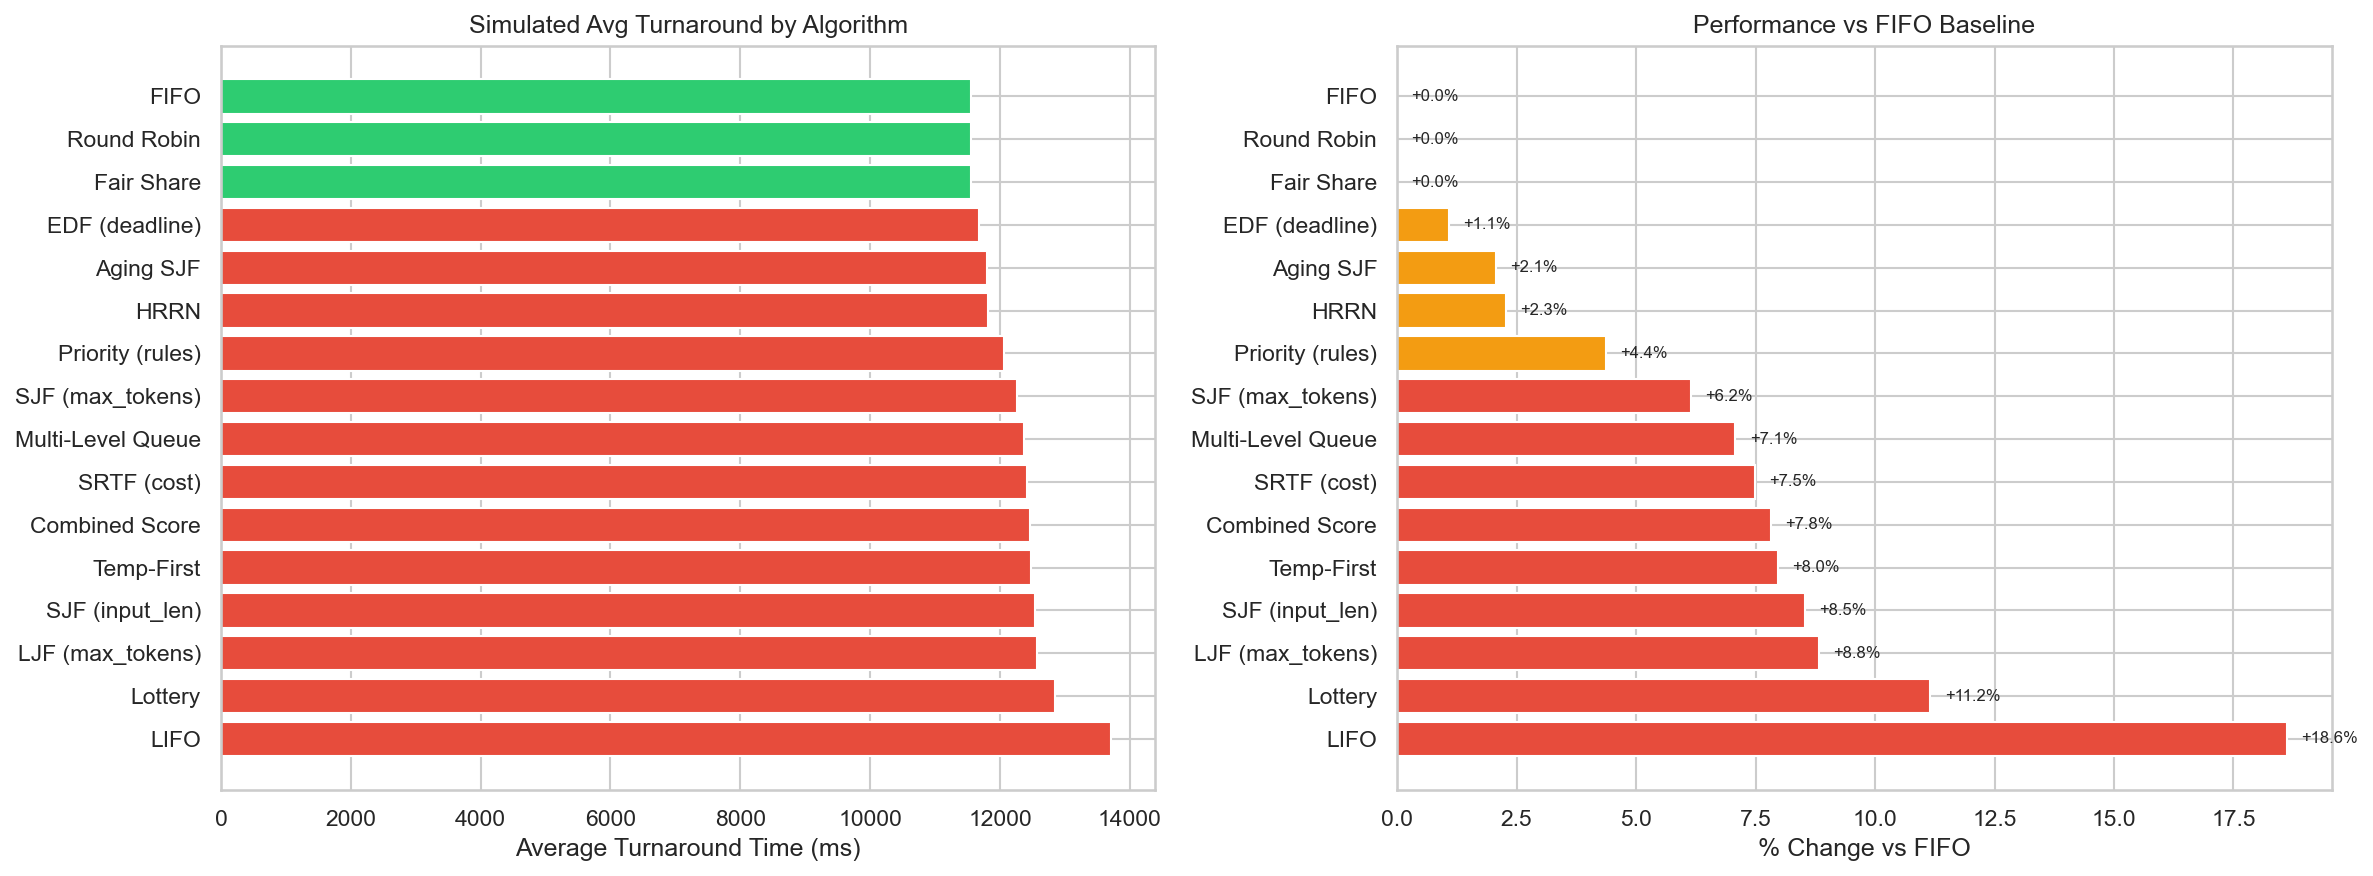

In [11]:
sim_path = PROJECT_ROOT / 'models' / 'simulation_results.csv'
if sim_path.exists():
    sim_df = pd.read_csv(sim_path)
    display(sim_df[['algorithm','avg_wait_ms','avg_turnaround_ms','vs_fifo_pct']].round(1))

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    # Average turnaround comparison
    colors = ['#2ecc71' if v <= 0 else '#e74c3c' for v in sim_df['vs_fifo_pct']]
    axes[0].barh(sim_df['algorithm'], sim_df['avg_turnaround_ms'], color=colors, edgecolor='white')
    axes[0].set_xlabel('Average Turnaround Time (ms)')
    axes[0].set_title('Simulated Avg Turnaround by Algorithm')
    axes[0].invert_yaxis()

    # Percentage vs FIFO
    colors2 = ['#2ecc71' if v <= 0 else '#f39c12' if v < 5 else '#e74c3c' for v in sim_df['vs_fifo_pct']]
    axes[1].barh(sim_df['algorithm'], sim_df['vs_fifo_pct'], color=colors2, edgecolor='white')
    axes[1].set_xlabel('% Change vs FIFO')
    axes[1].set_title('Performance vs FIFO Baseline')
    axes[1].axvline(0, color='black', lw=0.8)
    axes[1].invert_yaxis()
    for i, v in enumerate(sim_df['vs_fifo_pct']):
        axes[1].text(v + 0.3, i, f'{v:+.1f}%', va='center', fontsize=8)

    plt.tight_layout()
    plt.savefig(PROJECT_ROOT / 'models' / 'scheduling_simulation.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print('No simulation_results.csv found. Run simulate_schedulers.py first.')

## 11. Per-Class Wait Time: SJF vs FIFO (the tradeoff)

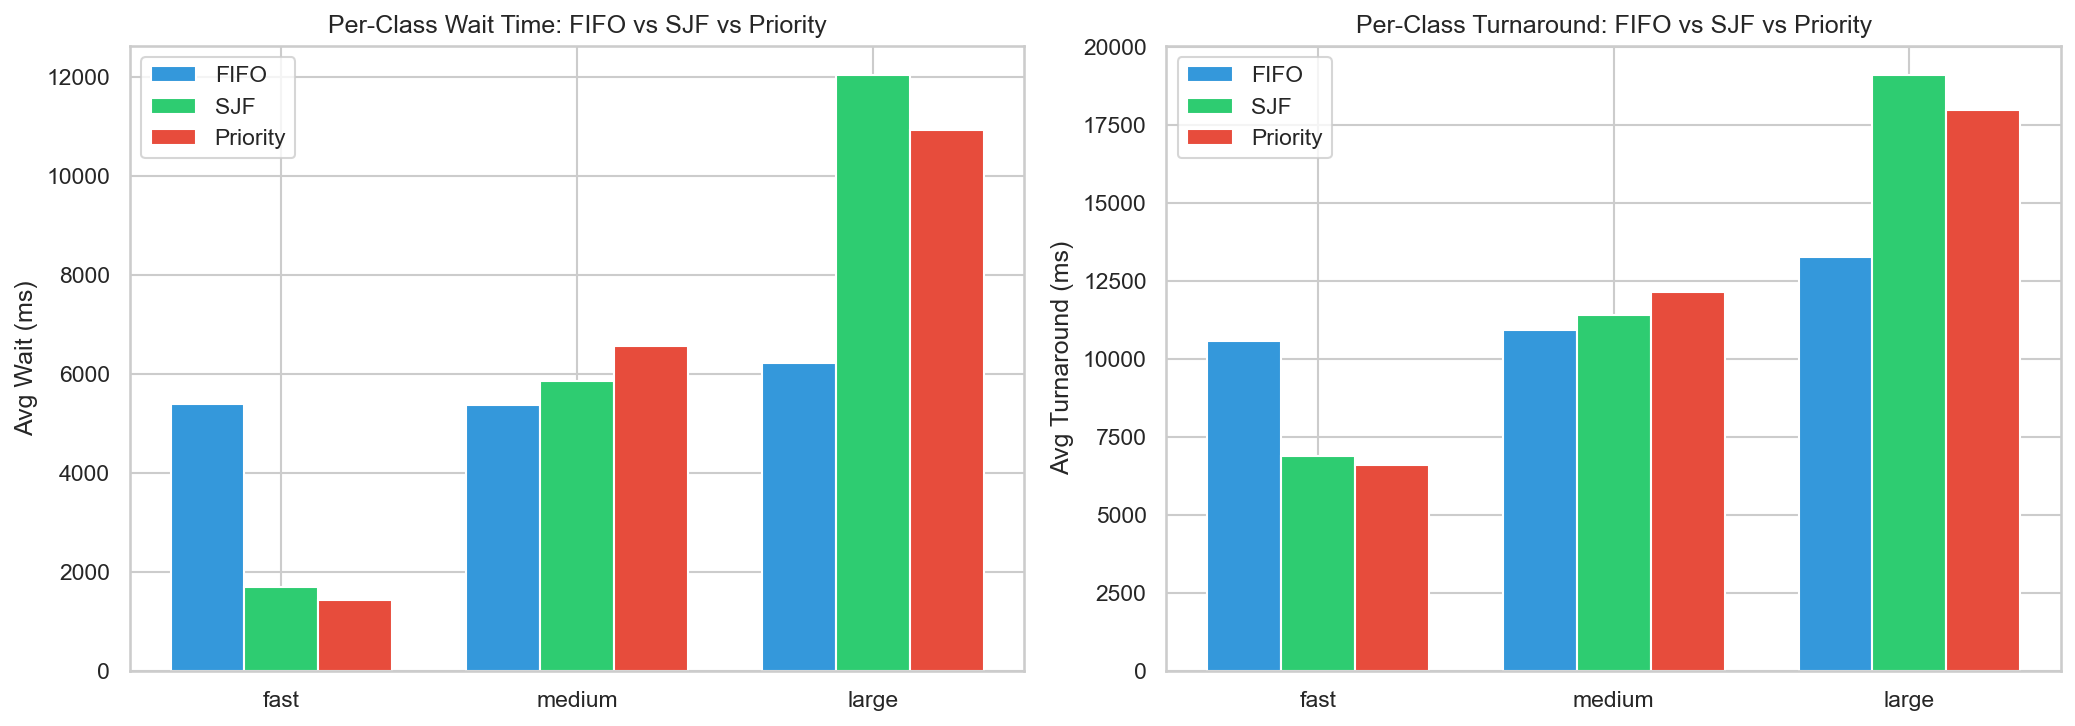


SJF reduces fast-task wait by 68% but increases large-task wait by 94%
Priority reduces fast-task wait by 73% but increases large-task wait by 76%


In [12]:
if sim_path.exists():
    fifo_row = sim_df[sim_df.algorithm == 'FIFO'].iloc[0]
    sjf_row = sim_df[sim_df.algorithm == 'SJF (max_tokens)'].iloc[0]
    pri_row = sim_df[sim_df.algorithm == 'Priority (rules)'].iloc[0]

    classes = ['fast', 'medium', 'large']
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Wait time comparison
    x = np.arange(len(classes))
    w = 0.25
    fifo_waits = [fifo_row[f'{c}_avg_wait'] for c in classes]
    sjf_waits = [sjf_row[f'{c}_avg_wait'] for c in classes]
    pri_waits = [pri_row[f'{c}_avg_wait'] for c in classes]

    axes[0].bar(x - w, fifo_waits, w, label='FIFO', color='#3498db', edgecolor='white')
    axes[0].bar(x, sjf_waits, w, label='SJF', color='#2ecc71', edgecolor='white')
    axes[0].bar(x + w, pri_waits, w, label='Priority', color='#e74c3c', edgecolor='white')
    axes[0].set_xticks(x)
    axes[0].set_xticklabels(classes)
    axes[0].set_ylabel('Avg Wait (ms)')
    axes[0].set_title('Per-Class Wait Time: FIFO vs SJF vs Priority')
    axes[0].legend()

    # Turnaround comparison
    fifo_turns = [fifo_row[f'{c}_avg_turn'] for c in classes]
    sjf_turns = [sjf_row[f'{c}_avg_turn'] for c in classes]
    pri_turns = [pri_row[f'{c}_avg_turn'] for c in classes]

    axes[1].bar(x - w, fifo_turns, w, label='FIFO', color='#3498db', edgecolor='white')
    axes[1].bar(x, sjf_turns, w, label='SJF', color='#2ecc71', edgecolor='white')
    axes[1].bar(x + w, pri_turns, w, label='Priority', color='#e74c3c', edgecolor='white')
    axes[1].set_xticks(x)
    axes[1].set_xticklabels(classes)
    axes[1].set_ylabel('Avg Turnaround (ms)')
    axes[1].set_title('Per-Class Turnaround: FIFO vs SJF vs Priority')
    axes[1].legend()

    plt.tight_layout()
    plt.savefig(PROJECT_ROOT / 'models' / 'perclass_comparison.png', dpi=150, bbox_inches='tight')
    plt.show()

    # Print the key numbers
    print('\nSJF reduces fast-task wait by {:.0f}% but increases large-task wait by {:.0f}%'.format(
        (1 - sjf_waits[0]/fifo_waits[0]) * 100,
        (sjf_waits[2]/fifo_waits[2] - 1) * 100
    ))
    print('Priority reduces fast-task wait by {:.0f}% but increases large-task wait by {:.0f}%'.format(
        (1 - pri_waits[0]/fifo_waits[0]) * 100,
        (pri_waits[2]/fifo_waits[2] - 1) * 100
    ))

## 12. Temporal Patterns

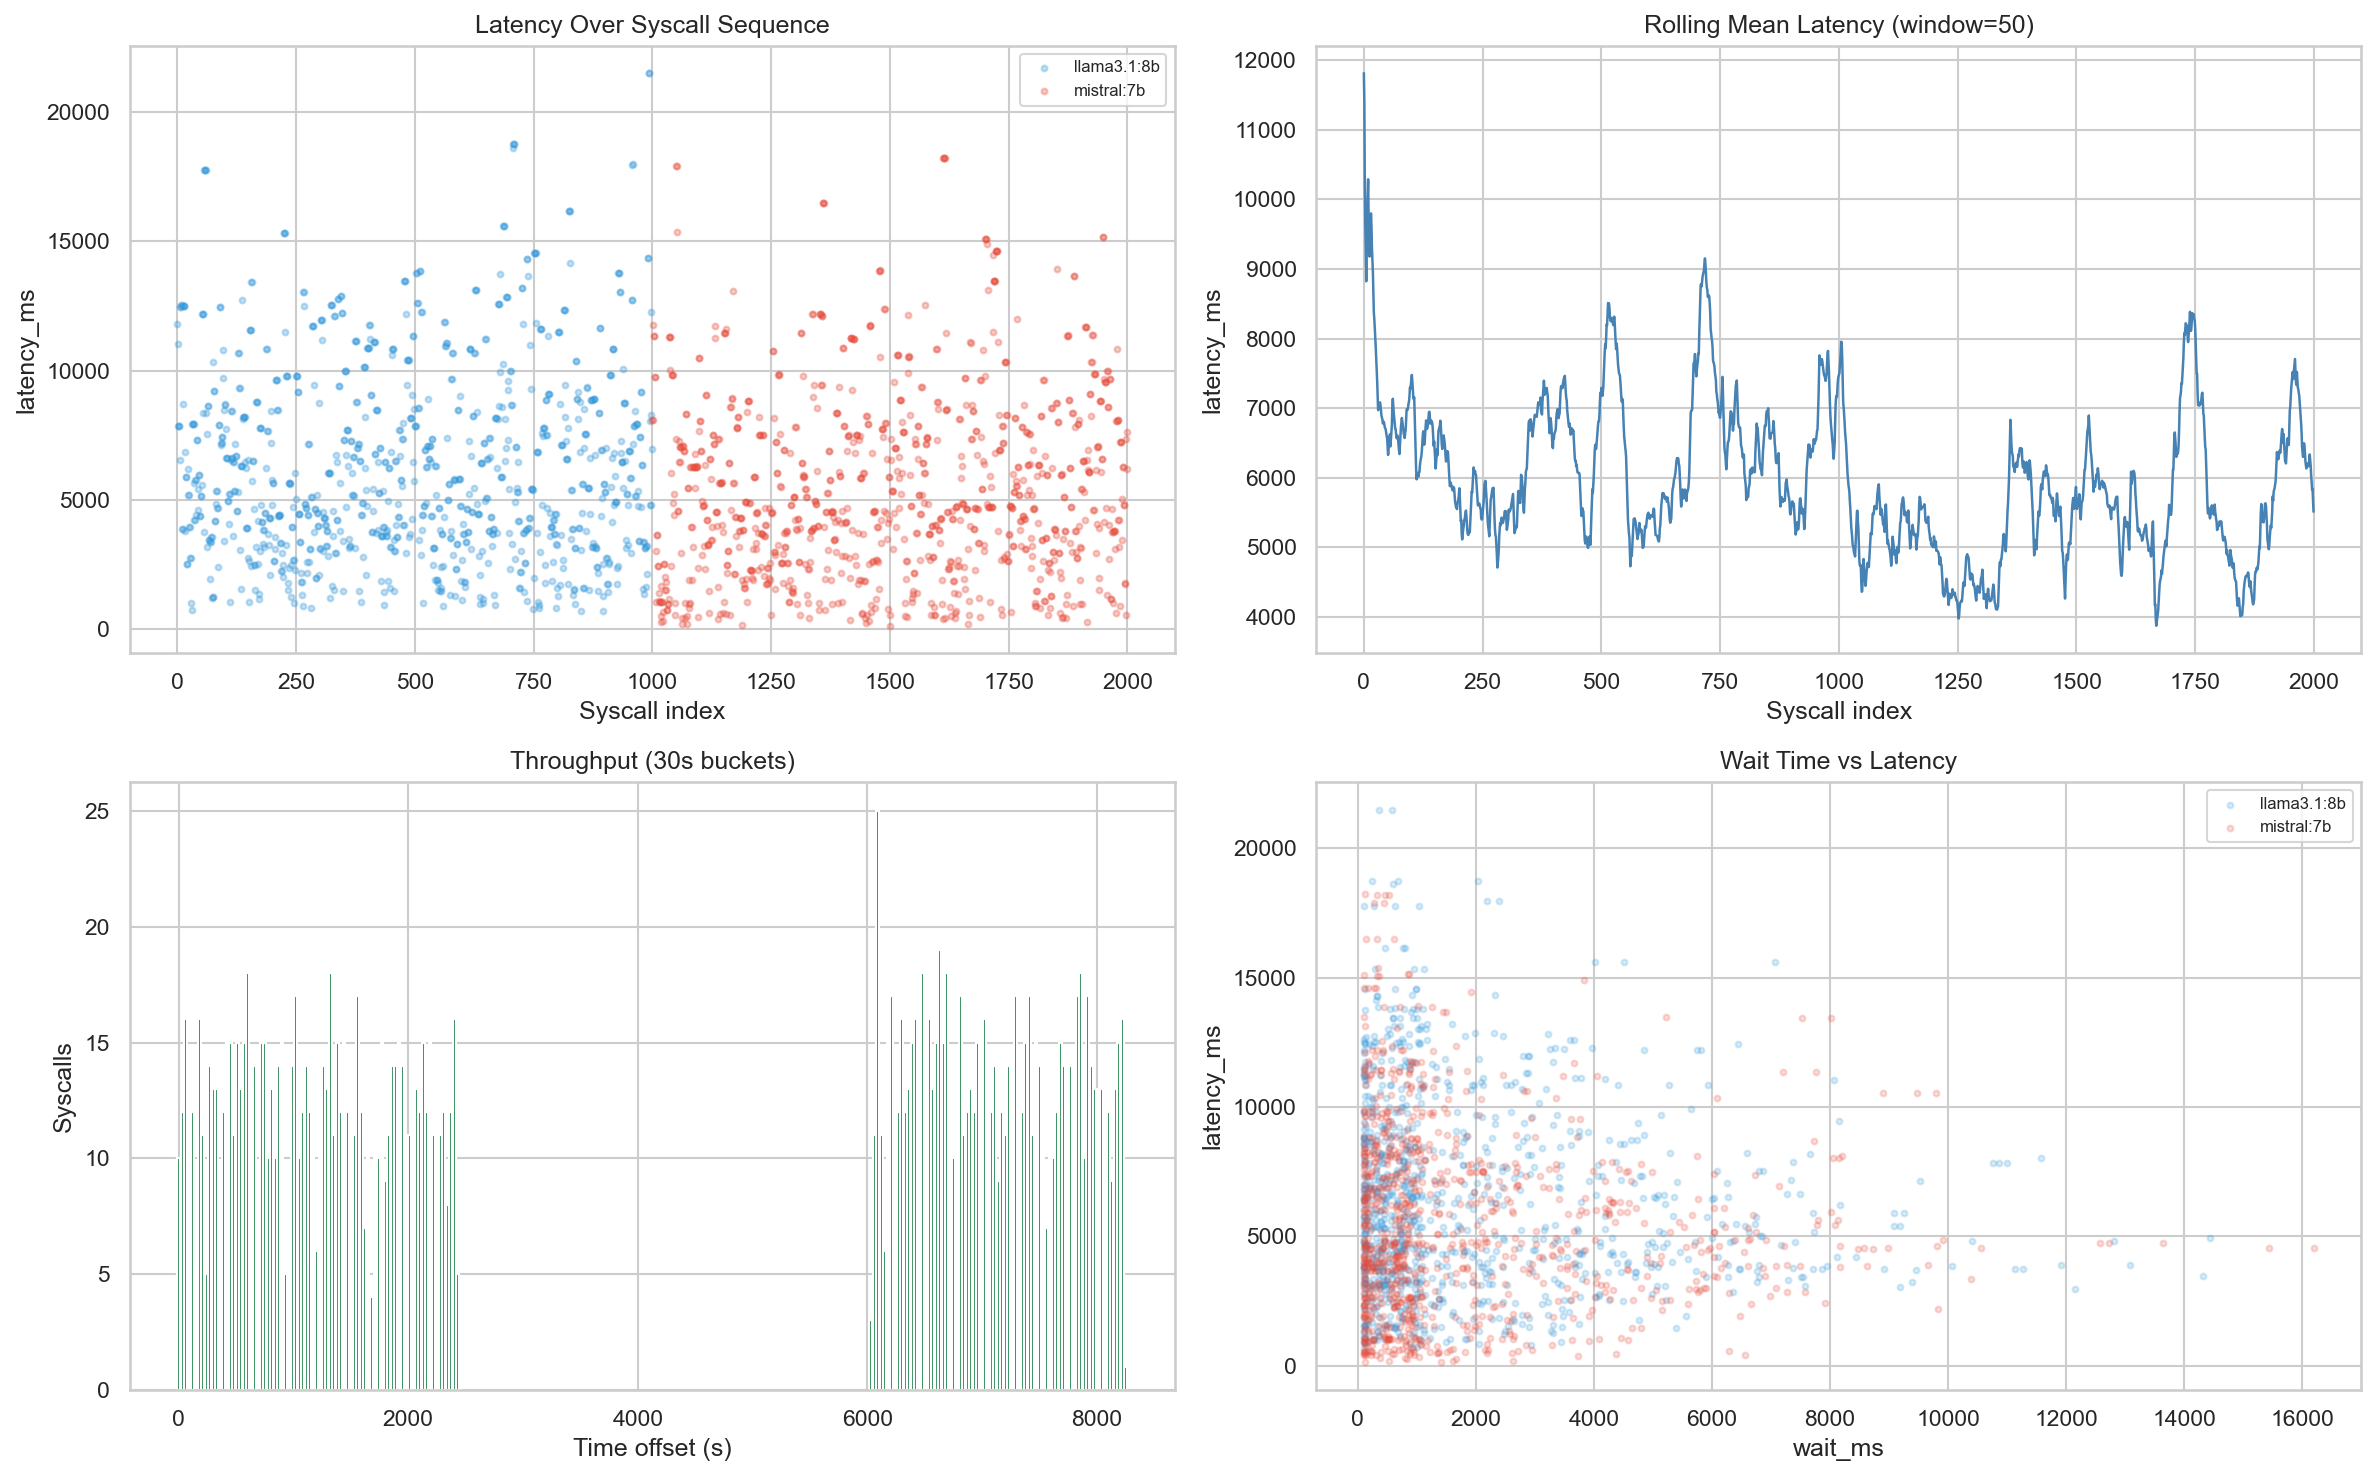

In [13]:
df_sorted = df.sort_values('timestamp').reset_index(drop=True)

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Latency over time by model
for model, grp in df_sorted.groupby('model_name'):
    axes[0,0].scatter(grp.index, grp['latency_ms'], alpha=0.3, s=8, label=model, color=palette.get(model))
axes[0,0].set_title('Latency Over Syscall Sequence')
axes[0,0].set_xlabel('Syscall index')
axes[0,0].set_ylabel('latency_ms')
axes[0,0].legend(fontsize=8)

# Rolling mean
df_sorted['rolling_lat'] = df_sorted['latency_ms'].rolling(50, min_periods=1).mean()
axes[0,1].plot(df_sorted.index, df_sorted['rolling_lat'], color='steelblue', lw=1.2)
axes[0,1].set_title('Rolling Mean Latency (window=50)')
axes[0,1].set_xlabel('Syscall index')
axes[0,1].set_ylabel('latency_ms')

# Throughput buckets
df_sorted['time_offset'] = df_sorted['timestamp'] - df_sorted['timestamp'].min()
bucket = 30
df_sorted['bucket'] = (df_sorted['time_offset'] // bucket).astype(int) * bucket
throughput = df_sorted.groupby('bucket').size()
axes[1,0].bar(throughput.index, throughput.values, width=bucket*0.8, color='seagreen', edgecolor='white')
axes[1,0].set_title(f'Throughput ({bucket}s buckets)')
axes[1,0].set_xlabel('Time offset (s)')
axes[1,0].set_ylabel('Syscalls')

# Latency vs wait scatter colored by model
for model, grp in df.groupby('model_name'):
    axes[1,1].scatter(grp['wait_ms'], grp['latency_ms'], alpha=0.2, s=8, label=model, color=palette.get(model))
axes[1,1].set_xlabel('wait_ms')
axes[1,1].set_ylabel('latency_ms')
axes[1,1].set_title('Wait Time vs Latency')
axes[1,1].legend(fontsize=8)

plt.tight_layout()
plt.savefig(PROJECT_ROOT / 'models' / 'temporal_patterns.png', dpi=150, bbox_inches='tight')
plt.show()

## 13. Summary Statistics Table (for paper)

In [14]:
summary = df[['input_char_length','message_count','max_tokens','temperature','latency_ms','wait_ms']].describe().T
summary['skew'] = df[['input_char_length','message_count','max_tokens','temperature','latency_ms','wait_ms']].skew()
summary['range'] = summary['max'] - summary['min']
display(summary[['count','mean','std','min','50%','max','skew','range']].round(1))

print('\n--- Unique values ---')
print(f'max_tokens:    {sorted(df.max_tokens.unique())}')
print(f'temperature:   {sorted(df.temperature.unique())}')
print(f'message_count: {sorted(df.message_count.unique())}')
print(f'model_name:    {sorted(df.model_name.unique())}')
print(f'agent_type:    {sorted(df.agent_type.unique())}')
print(f'has_tools:     True={df.has_tools.sum()}, False={len(df)-df.has_tools.sum()}')

,count,mean,std,min,50%,max,skew,range
input_char_length,2000.0,909.3,611.3,165.0,698.0,2658.0,1.1,2493.0
message_count,2000.0,3.2,2.1,2.0,2.0,8.0,1.4,6.0
max_tokens,2000.0,647.9,685.4,64.0,256.0,2048.0,1.2,1984.0
temperature,2000.0,0.5,0.3,0.1,0.5,1.0,0.1,0.9
latency_ms,2000.0,5931.7,3631.2,143.1,5235.1,21484.5,0.8,21341.4
wait_ms,2000.0,1898.4,2299.0,102.5,902.3,16196.5,2.1,16094.0



--- Unique values ---
max_tokens:    [np.int64(64), np.int64(128), np.int64(256), np.int64(512), np.int64(1024), np.int64(2048)]
temperature:   [np.float64(0.1), np.float64(0.2), np.float64(0.3), np.float64(0.5), np.float64(0.7), np.float64(0.9), np.float64(1.0)]
message_count: [np.int64(2), np.int64(4), np.int64(6), np.int64(8)]
model_name:    ['llama3.1:8b', 'mistral:7b']
agent_type:    ['code_gen_agent', 'long_reasoning_agent', 'short_qa_agent', 'summarizer_agent', 'tool_use_agent']
has_tools:     True=400, False=1600


## 14. Key Findings

### Dataset
- 2,000 syscalls: 1,000 from Llama 3.1:8b, 1,000 from Mistral:7b
- 5 agent types x 10 tasks x 20 rounds per model
- All features independently randomised (max_tokens, temperature, message_count, prompt length)
- Zero errors, zero interruptions

### Latency drivers
- `max_tokens` is the strongest predictor (Spearman rho = 0.206), but still weak
- `model_name` contributes (rho = 0.132): Llama ~920ms slower than Mistral at median
- `input_char_length`, `temperature`, `message_count` show negligible correlation
- Scheduler queue position (wait_ms) dominates actual turnaround

### Classifier performance
- Best model: Gradient Boosting (F1 = 0.47, barely above random)
- Root cause: latency depends on batched execution timing, not request features

### Scheduling simulation (16 algorithms)
- FIFO matches or beats all reordering algorithms on average turnaround
- SJF reduces fast-task wait by ~68% but increases large-task wait by ~94%
- For batched LLM inference, dispatch order within a batch has minimal impact
- The real benefit requires batch composition control (live runtime, not simulation)